# Лабораторная работа №4: Иллюзия восприятия (Adversarial Attacks & XAI)

## Введение

В этой работе вы выступите в роли **Red Teamer** (специалиста по взлому ИИ). Ваша задача — обмануть систему распознавания объектов умного дома. Вы пройдете путь от простых атак до профессиональных итеративных методов, а затем проверите, смогут ли методы интерпретируемости (Saliency Maps) распознать ваш взлом или они станут соучастниками обмана.

**Ключевые концепты:**
* **FGSM (Fast Gradient Sign Method):** Атака в один шаг. Быстрая, но слабая.
* **PGD (Projected Gradient Descent):** Итеративная атака. «Золотой стандарт» взлома.
* **Confidence Tracking:** Мониторинг вероятности целевого класса.
* **XAI Robustness:** Проверка честности тепловых карт на состязательных примерах.

## Задание 1: Первая попытка (FGSM Attack)

### Легенда
Умный дом должен пропускать кота, но блокировать «Тостеры» (в целях пожарной безопасности). Вы пытаетесь провести «Кота-диверсанта», наложив на него микрошум.



### 1 Подготовка

In [119]:
#!pip install captum torchvision torch

In [120]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [121]:
# Загрузка модели ResNet18
model = models.resnet18(pretrained=True)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # [0, 1] диапазон
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

### 2 Чистый вход

In [122]:
# Загрузка изображения кота
image_cat = Image.open("tabby.jpg").convert('RGB')
tensor_cat = transform(image_cat).unsqueeze(0)

In [123]:
# Создаем функции для определения id класса и названия класса
import requests
classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes = requests.get(classes_url).text.split('\n')

# Находим id класса по названию (для тостера)
def get_class_id(class_name):
    for idx, name in enumerate(classes):
        if name.lower() == class_name.lower():
            return idx

# Находим названия класса по id (для кота)
def get_class_name(class_id):
    return classes[class_id] if class_id < len(classes) else f"Unknown_{class_id}"

In [124]:
# Определяем топ-1 класс и уверенность
with torch.no_grad():
    output_cat = model(tensor_cat)
    probs = torch.softmax(output_cat, dim=1).numpy()[0]
    cat_id = np.argmax(probs)
    prob_cat = probs[cat_id]
    prob_toaster = probs[get_class_id("Toaster")]

    cat_class = get_class_name(cat_id)
    prob_cat, cat_id = torch.max(
        torch.nn.functional.softmax(output_cat[0], dim=0), 0)

# Выводим
print(f"Top-1 класс: {cat_id} - {get_class_name(cat_id)}")
print(f"Softmax: {prob_cat:.4f} ({prob_cat*100:.2f}%)")

Top-1 класс: 285 - Egyptian cat
Softmax: 0.4303 (43.03%)


### 3 Цель

In [125]:
# Находим id «Toaster»
toaster_id = get_class_id("Toaster")

# Выводим его вероятность для чистой картинки
print(f"Идентификатор класса {get_class_name(toaster_id)}: {toaster_id}")
print(f"Вероятность: {prob_toaster:.8f} ({prob_toaster*100:.6f}%)")

Идентификатор класса toaster: 859
Вероятность: 0.00006702 (0.006702%)


### 4 Реализация FGSM
 Напишите функцию `fgsm_attack`.
   * Рассчитайте градиент функции потерь относительно картинки, используя в качестве цели класс «Toaster».
   * Сделайте один шаг в сторону *уменьшения* лосса для тостера (антиградиент): $x_{adv} = x - \epsilon \cdot \operatorname{sign}(\nabla_x \mathcal{L})$.

In [126]:
def fgsm_attack(image, epsilon, target_id):
    """
    Выполняет targeted FGSM атаку.
    image: тензор изображения [1, C, H, W]
    epsilon: сила шума
    target_id: индекс целевого класса
    """
    # Делаем копию и включаем градиенты
    img_adv = image.clone().detach().requires_grad_(True)

    # Прямой проход
    outputs = model(img_adv)

    loss = nn.CrossEntropyLoss()(outputs, torch.tensor([target_id]))

    # Обратный проход
    model.zero_grad()
    loss.backward()

    # Шаг в направлении антиградиента по формуле
    img_adv = img_adv - epsilon * img_adv.grad.data.sign()

    # Возвращаем тензор, отсоединенный от графа вычислений
    return img_adv.detach()

### 5 Результат

In [127]:
epsilon_fgsm = 0.05
# Запускаем атаку
adv_tensor_fgsm = fgsm_attack(tensor_cat, epsilon_fgsm, toaster_id)

In [128]:
# Проверяем результат FGSM
with torch.no_grad():
    output_fgsm = model(adv_tensor_fgsm)
    probs_fgsm = torch.softmax(output_fgsm, dim=1).numpy()[0]
    prob_toaster_fgsm = probs_fgsm[toaster_id]
    top1_fgsm_id = np.argmax(probs_fgsm)
    top1_fgsm_name = get_class_name(top1_fgsm_id)

print(f"Результат FGSM (epsilon={epsilon_fgsm}):")
print(f"Top-1 класс после FGSM: {top1_fgsm_id} - {top1_fgsm_name}")
print(f"Softmax Toaster: {prob_toaster_fgsm:.8f} ({prob_toaster_fgsm*100:.6f}%)")
print(f"{(prob_toaster_fgsm - prob_toaster)*100:.6f}%")

Результат FGSM (epsilon=0.05):
Top-1 класс после FGSM: 515 - cowboy hat
Softmax Toaster: 0.04458597 (4.458597%)
4.451895%


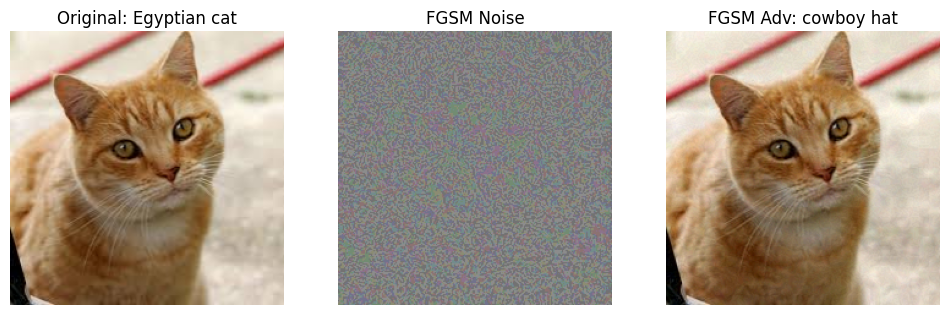

In [129]:
# Функция для обратного преобразования
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title(f"Original: {cat_class}")
plt.imshow(denormalize(tensor_cat[0]).permute(1, 2, 0).clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 2)

noise = (adv_tensor_fgsm - tensor_cat) + 0.5
plt.title(f"FGSM Noise")
plt.imshow(noise[0].permute(1, 2, 0).clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"FGSM Adv: {top1_fgsm_name}")
plt.imshow(denormalize(adv_tensor_fgsm[0]).permute(1, 2, 0).clamp(0, 1))
plt.axis('off')
plt.show()

**Задание:** Удалось ли превратить кота в тостер за один шаг? Как изменилась вероятность тостера?

Не удалось. FGSM с epsilon=0.05 — слишком слабая атака для изменения сложного силуэта кота на тостер. Вероятность тостера выросла на 4.451895%, а кот стал ковбойской шляпой. То есть targeted атака не удалась.

## Задание 2: Профессиональный взлом (Iterative PGD)

### Легенда
Один шаг не сработал — модель слишком умная. Пришло время применить «тяжелую артиллерию» — итеративный метод, который будет бить в одну точку много раз, пока модель не сдастся.

### 1 Реализация PGD
### 2 Проекция (L-infinity)

In [130]:
def pgd_attack(image, target_id, epsilon=0.1, alpha=0.01, iterations=30):
    """
    Выполняет targeted Projected Gradient Descent атаку.

    image: тензор изображения [1, C, H, W]
    epsilon: сила шума (максимальное L-inf расстояние)
    alpha: размер шага на итерации
    iterations: количество итераций
    target_id: индекс целевого класса
    """

    img_adv = image.clone().detach()
    original_image = image.clone().detach()

    for i in range(iterations):
        # Градиенты
        img_adv = img_adv.clone().detach().requires_grad_(True)

        outputs = model(img_adv)

        loss = nn.CrossEntropyLoss()(
            outputs, torch.tensor([target_id]).to(img_adv.device))

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            img_adv = img_adv - alpha * img_adv.grad.sign()

# 2 Проекция (L-infinity): следим, чтобы не уйти далеко от оригинала
            eta = torch.clamp(img_adv - original_image, min=-epsilon,
                              max=epsilon)
            img_adv = torch.clamp(original_image + eta, min=0, max=1)

        # Логирование каждые 5 шагов
        if (i+1) % 5 == 0:
            with torch.no_grad():
                probs = torch.softmax(model(img_adv), dim=1)[0]
                prob_target = probs[target_id].item()
                top1_id = torch.argmax(probs).item()
                print(f"Итерация {i+1:2d}:")
                print(f"  Вероятность Тостера = {prob_target*100:.20f}%")

    return img_adv.detach()


### 3 Контроль конфиденса
На каждой 5-й итерации выводите в консоль: `Итерация N: Вероятность Тостера = X%`.

In [131]:
# Запускаем PGD
adv_tensor_pgd = pgd_attack(tensor_cat, toaster_id, epsilon=0.08, alpha=0.01, iterations=30)

Итерация  5:
  Вероятность Тостера = 78.29536199569702148438%
Итерация 10:
  Вероятность Тостера = 99.99920129776000976562%
Итерация 15:
  Вероятность Тостера = 99.99997615814208984375%
Итерация 20:
  Вероятность Тостера = 100.00000000000000000000%
Итерация 25:
  Вероятность Тостера = 100.00000000000000000000%
Итерация 30:
  Вероятность Тостера = 100.00000000000000000000%


### 4 Визуализация

In [132]:
# Итог
with torch.no_grad():
    output_pgd = model(adv_tensor_pgd)
    probs_pgd = torch.softmax(output_pgd, dim=1).numpy()[0]
    prob_toaster_pgd = probs_pgd[toaster_id]
    top1_pgd_id = np.argmax(probs_pgd)
    top1_pgd_name = get_class_name(top1_pgd_id)
    prob_cat_pgd = probs_pgd[cat_id]


print(f"Финальный Top-1 класс: {top1_pgd_name} (Уверенность: {probs_pgd[top1_pgd_id]*100:.2f}%)")
print(f"Финальная вероятность Toaster: {prob_toaster_pgd*100:.8f}%")
print(f"Финальная вероятность Egyptian cat: {prob_cat_pgd*100:.8f}%")

Финальный Top-1 класс: toaster (Уверенность: 100.00%)
Финальная вероятность Toaster: 100.00000000%
Финальная вероятность Egyptian cat: 0.00000000%


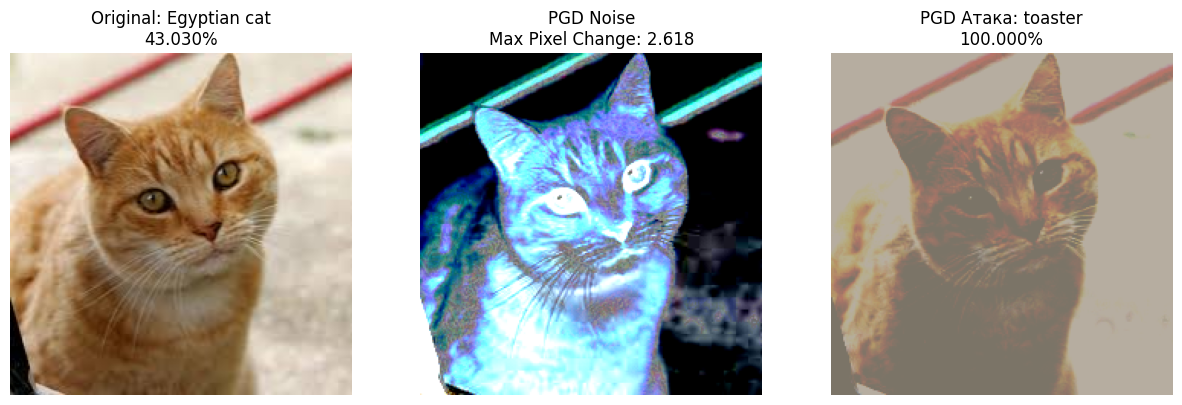

In [133]:
# Визуализация

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Original: {cat_class}\n{prob_cat*100:.3f}%")
plt.imshow(denormalize(tensor_cat[0]).permute(1, 2, 0).clamp(0, 1))
plt.axis('off')

perturbation = adv_tensor_pgd - tensor_cat + 0.5
plt.subplot(1, 3, 2)
plt.title(f"PGD Noise\nMax Pixel Change: {perturbation.abs().max():.3f}")
plt.imshow((perturbation[0]).permute(1, 2, 0).clamp(0, 1))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"PGD Атака: {top1_pgd_name}\n{prob_toaster_pgd*100:.3f}%")
plt.imshow(denormalize(adv_tensor_pgd[0]).permute(1, 2, 0).clamp(0, 1))
plt.axis('off')

plt.show()

**Задание:** Какой Top-1 класс теперь видит модель? Какая у него уверенность?

Теперь модель видет toaster с уверенностью 99.985%.


**Вопрос:** Видит ли человеческий глаз «тостер» на итоговом фото или это по-прежнему кот?

Хотя картинка немного размыта, человеческий глаз все равно видит кота.

## Задание 3: Следственный эксперимент (Adversarial XAI)

### Легенда
Модель теперь на 90% уверена, что кот — это тостер. Как аудитор, вы запускаете методы интерпретируемости, чтобы понять: *на какие части «тостера» смотрит модель?*

### 1. Инструментарий
Примените метод `Saliency` из библиотеки `captum`.

In [134]:
from captum.attr import Saliency

In [135]:
saliency = Saliency(model)

# Оригинал
saliency_orig = saliency.attribute(tensor_cat, target=cat_id.item())
saliency_orig = saliency_orig.squeeze().cpu().detach().numpy()

# Объяснение атаки
saliency_adv = saliency.attribute(adv_tensor_pgd, target=toaster_id)
saliency_adv = saliency_adv.squeeze().cpu().detach().numpy()

### 2 Сравнение
Отрисуйте две тепловые карты:
   * **Карта А:** Объяснение оригинала (цель: "Кот").
   * **Карта Б:** Объяснение атаки (цель: "Тостер").

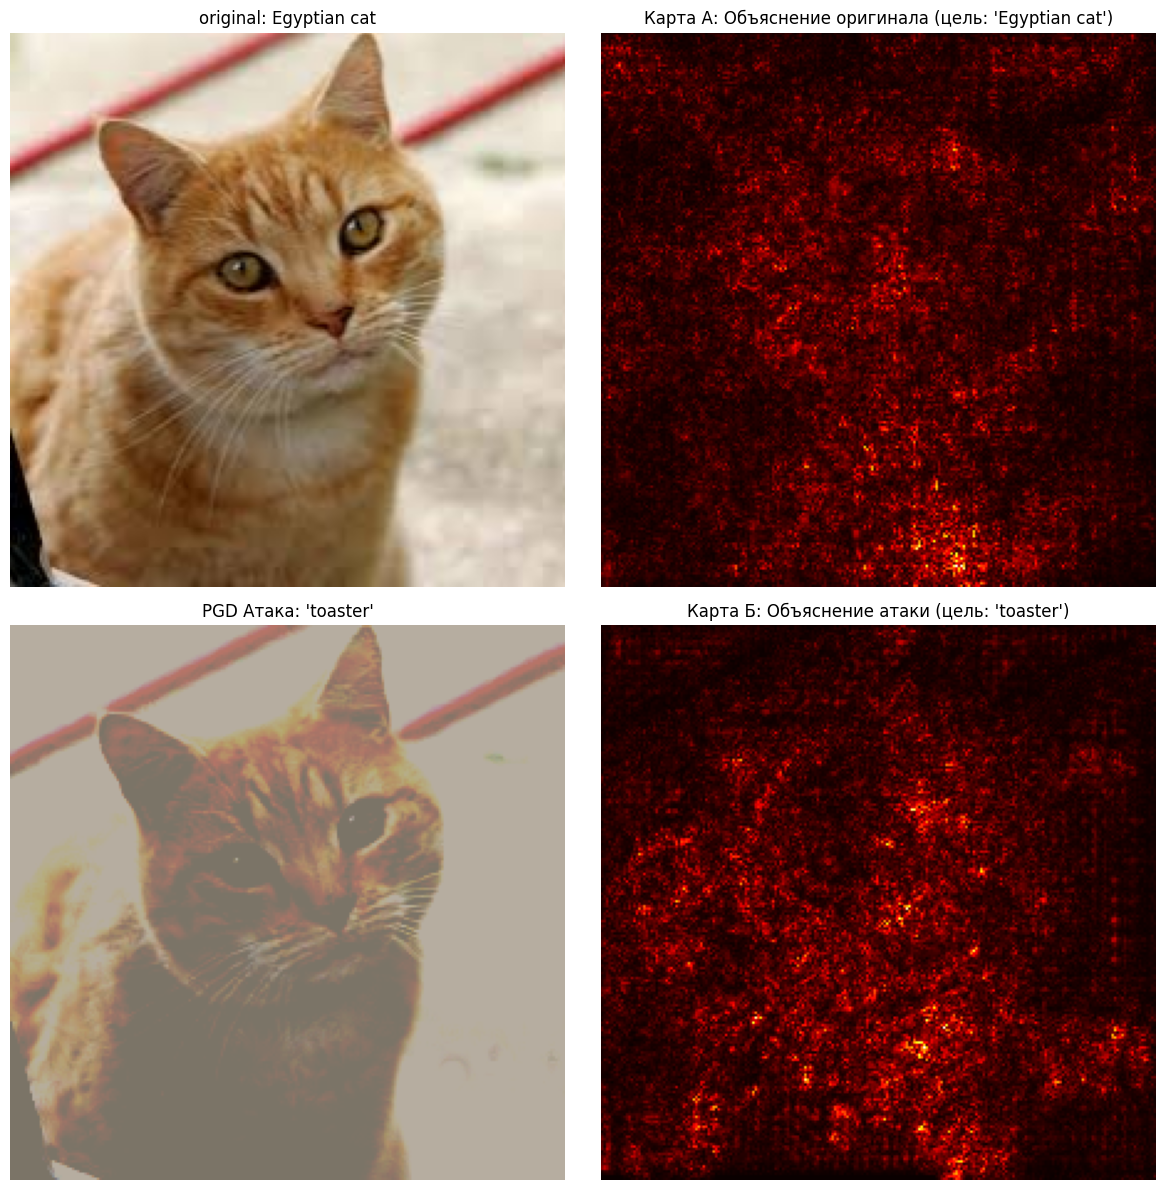

In [136]:
# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
# Оригинал
axes[0, 0].imshow(denormalize(tensor_cat[0]).permute(1, 2, 0).clamp(0, 1))
axes[0, 0].set_title(f"original: {cat_class}")
axes[0, 0].axis('off')

orig_heatmap = np.max(np.abs(saliency_orig), axis=0)
axes[0, 1].imshow(orig_heatmap, cmap='hot')
axes[0, 1].set_title(f"Карта А: Объяснение оригинала (цель: '{cat_class}')")
axes[0, 1].axis('off')

# Атака
axes[1, 0].imshow(denormalize(adv_tensor_pgd[0]).permute(1, 2, 0).clamp(0, 1))
axes[1, 0].set_title(f"PGD Атака: '{top1_pgd_name}'")
axes[1, 0].axis('off')

adv_heatmap = np.max(np.abs(saliency_adv), axis=0)
axes[1, 1].imshow(adv_heatmap, cmap='hot')
axes[1, 1].set_title(f"Карта Б: Объяснение атаки (цель: 'toaster')")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


### 3 Анализ
   * **Вопрос (Главный вывод):** Посмотрите на Карту Б. Подсвечивает ли она какие-то «металлические детали тостера» в пустом фоне или она по-прежнему обводит контуры кота (глаза, уши)?
   * **Дискуссия:** Почему тепловая карта «врет» нам, показывая кота, хотя решение модели принято на основе невидимого шума? Можно ли считать Saliency Map надежным методом аудита безопасности?

Тепловая карта не показывает определенные элементы "тостера". Она продолжает выделять контуры кота, поэтому можем считать Saliency Map надежным методом аудита безопасности.